## Objective: 
Predicting the stock prices in the future is an important use-case in finance. If we can build a model with reasonable accuracy which can help us in predicting the movement of the stock prices for an asset, it can yield good returns.

The Long Short Term Memory (LSTM) networks are a refined version of Recurrent Neural Network (RNN) which perform well on such problems.

### RNN (Recurrent Neural Network)

Type of neural network designed for sequential data, where the order of inforamtion matters. 

Unlike a normal neural( which treats every input as independent), an RNN remembers previous input and uses that information to process the current input.
Examples of Sequential data: 
Stock prices over time
Text Sentences
Speech Signals etc

### Basic Idea of RNN
Consider, we have stock returns: r1, r2, r3....rn
A normal neural network treats every input independently: yt = f(xt)

It only knows the current input, doesn't keep track of previous state. Whereas, An RNN maintains a hidden state: ht which stores information from previous time steps.
The update is:
ht = f(WxXt + WhHt-1 + b) where:
Xt = current input 
Ht-1 = previous memory
Ht = updated memory
Wx, Wh = weights
b = bias 
The output : yt = g(Wyht) which is activation function(weight*updated memory).

Activation Function : The function g converts the raw output into the required format.

### RNN architecture

Imagine predicting today's stock movement: 
Day 1 Return      Day 2 Return       Day 3 Return
    x1                x2                x3
    |                 |                 |
    v                 v                 v

   RNN ------------> RNN ------------> RNN
    |                 |                 |
   h1                h2                h3
                     |
                     v
              Prediction
The hidden state carries information forward: h1-> h2-> h3. Using this, model remembers previous days.

Using hidden states: model learns - Recent momentum
                                    Volatility patterns
                                    Trends
                                    Reversal patterns
and returns tomorrow's returns: +-0.3%

#### Approach: To predict stock prices using LSTM Technique of Machine Learning

In [3]:
## Importing the necessary Libraries
import yfinance as yf
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
from matplotlib.pylab import rcParams
# For data Normalization
from sklearn.preprocessing import MinMaxScaler
# sklearn.preprocessing: module in scikit - learn (sklearn) that contains tools for transforming and scaling data before feeding
# it into ml models.

# For building the model
# ==============================
# Keras Components Used
# ==============================

# Sequential:
# - Creates a neural network by stacking layers one after another.
# - Think of it as the container that holds the entire neural network model.

# LSTM (Long Short-Term Memory):
# - A recurrent neural network (RNN) layer designed for sequential/time-series data.
# - Learns patterns and long-term dependencies from past observations.
# - Example: Uses the previous 60 days of stock prices to predict the next day's price.

# Dropout:
# - Regularization technique to reduce overfitting.
# - Randomly disables a fraction of neurons during training (e.g., 0.2 = 20%).
# - Helps the model generalize better to unseen data.

# Dense:
# - Fully connected layer where every neuron receives input from all neurons
#   in the previous layer.
# - Usually used as the final layer to produce the prediction.
# - Dense(1) -> predicts a single continuous value (e.g., next day's stock price).
from keras.layers import LSTM, Dropout, Dense
from keras.models import Sequential
## Setting the figsize parameter for the plots in this notebook to standardize the size of plots
%matplotlib inline
rcParams['figure.figsize'] = 20,10

In [4]:
## Downloading the data for the MSFT stock
ticker = 'MSFT'
df = yf.download(ticker, period = '10y', auto_adjust = False, group_by = 'ticker')['MSFT']

[*********************100%***********************]  1 of 1 completed


In [5]:
df.head()

Price,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2016-07-05,50.830002,51.279999,50.740002,51.169998,45.240833,24806400
2016-07-06,50.779999,51.540001,50.389999,51.380001,45.426514,28167500
2016-07-07,51.419998,51.610001,51.070000,51.380001,45.426514,19585200
2016-07-08,51.730000,52.360001,51.549999,52.299999,46.239922,28391000
2016-07-11,52.500000,52.830002,52.470001,52.590000,46.496311,22269200


In [6]:
df.shape

(2513, 6)

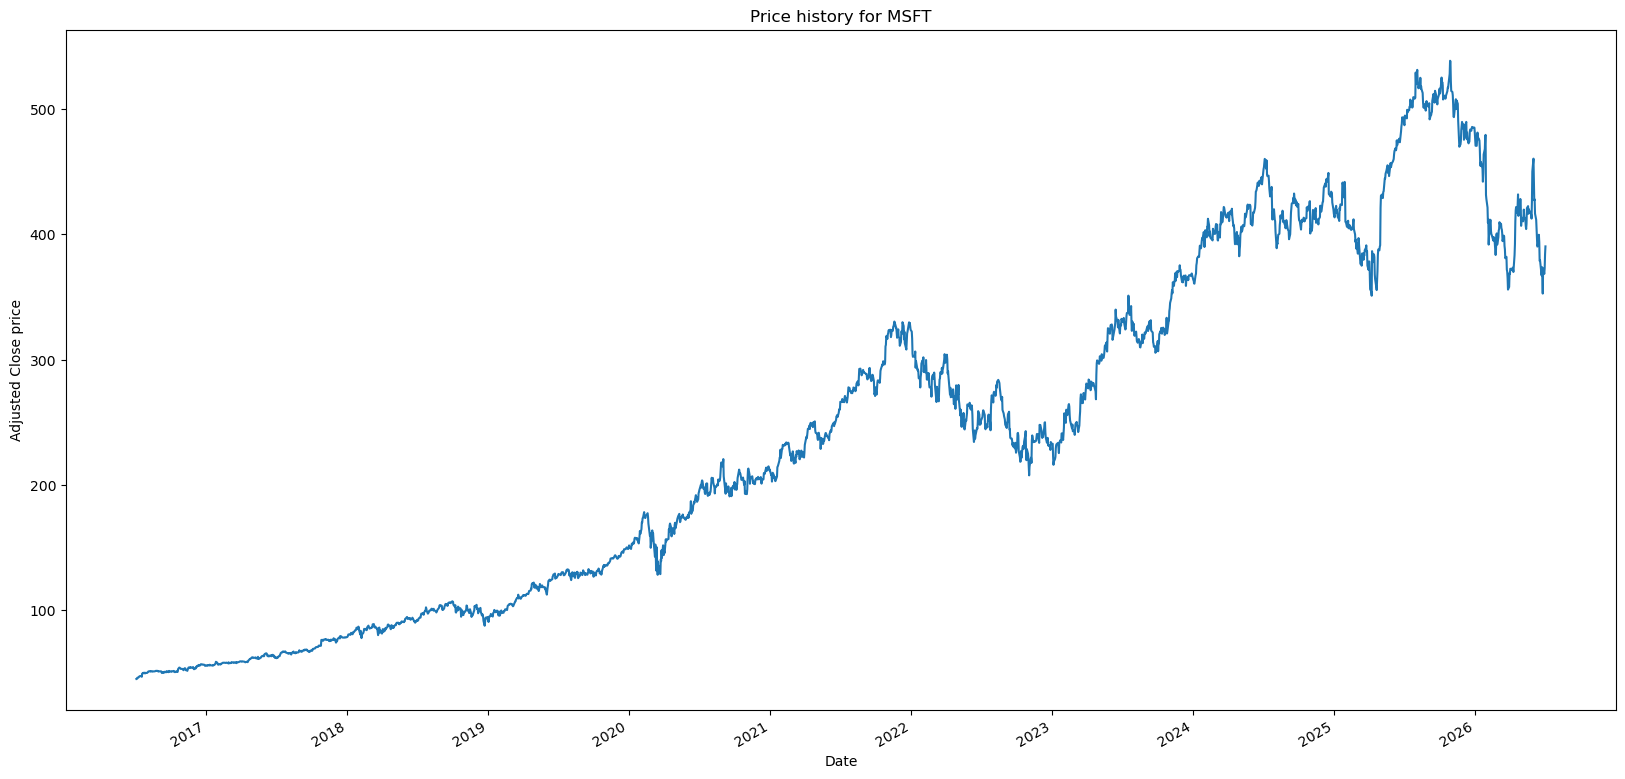

In [7]:
df['Adj Close'].plot()
plt.ylabel('Adjusted Close price')
plt.title(f'Price history for {ticker}')
plt.show()

In [8]:
# Data Pre-processing
# Filter the dataset 
# Data Pre-processing
# Filter the dataset (and drop any NaN rows yfinance may return)
df1 = df[['Adj Close']].dropna().copy()

In [9]:
df1.head()

Price,Adj Close
Date,
2016-07-05,45.240833
2016-07-06,45.426514
2016-07-07,45.426514
2016-07-08,46.239922
2016-07-11,46.496311


In [10]:
df1.shape

(2513, 1)

In [11]:
#Rename the column to Close for convenience
df1.rename(columns = {'Adj Close': 'Close'},inplace = True)   # inplace = True means modify the original object
# directly instead of creating a new copy.

In [12]:
# Normalize the filtered Dataset
prices = df1.values   # converts a pandas df into numpy array and store it into prices variable.

In [13]:
# Check the prices array
prices

array([[ 45.24083328],
       [ 45.42651367],
       [ 45.42651367],
       ...,
       [373.01998901],
       [384.27999878],
       [390.48999023]])

In [14]:
# Splitting the dataset
train_len = math.ceil(len(prices)*0.8)   # ceil means round up to the nearest integer.
train_len

2011

### Scaling the Data

- Reshape the `prices` array with `newshape` as (1, -1)
- What (1,-1) essentially does it just keeps the row as size 1 and columns are calculated automatically.
- For an RNN, the input is usually:
- (samples, time steps, features)
- For instance:
- prices.reshape(1, -1) gives:
- (samples, time_steps)

(1,5)
Then you may add the feature dimension:
prices.reshape(1,5,1)

Example:

Sample 1:

Day1   Day2   Day3   Day4   Day5

100    102    105    110    115

The RNN reads the sequence:

100 → 102 → 105 → 110 → 115

**Note**- _The new shape should be compatible with the original shape. If an integer, then the result will be a 1-D array of that length. One shape dimension can be -1. In this case, the value is inferred from the length of the array and remaining dimensions_
- Fit the scaler to the first `train_len` observations of the `prices`.
- Normalize the data to values between 0 and 1 using `MinMaxScaler`and save it as `scaled_prices`. Remember, that the feature range has to be passed as a tuple.

In [4]:
# Scaling the data
scaler = MinMaxScaler(feature_range = (0,1))  #scale the price in the range of (0,1) using formula: (X-Xmin)/(Xmax- Xmin)
scaler.fit(prices.reshape(-1,1)[:train_len, :])   
scaled_prices = scaler.transform(prices.reshape(-1,1))
# why prices.reshape(-1,1)?
# Because scikit-learn expects: (no.of samples, no.of features). So, for our case: where we have samples as days and feature as closed prices.
# we use reshape (-1,1) as we have only one feature and multiple samples.
# Now, imagine if we have 3 features and n observations then in that case, we could have directly done it like
# from sklearn.preprocessing import MinMaxScaler

# scaler = MinMaxScaler(feature_range=(0,1))

# scaled_X = scaler.fit_transform(X)
# because, here share is pretty much evident or like(-1,3) sort of, the scikit learn knows this behorehand whereas, in our case samples are (n) but 
#feature is just 1 so,it's shape is like (n,) so, it could be n or could be 1.

NameError: name 'MinMaxScaler' is not defined

In [16]:
# Checking the Scaled prices array
scaled_prices

array([[0.00000000e+00],
       [4.59124848e-04],
       [4.59124848e-04],
       ...,
       [8.10487072e-01],
       [8.38329270e-01],
       [8.53684480e-01]])

Creating the training and testing dataset

In [17]:
train_data = scaled_prices[0:train_len, :]

In [18]:
train_data

array([[0.00000000e+00],
       [4.59124848e-04],
       [4.59124848e-04],
       ...,
       [9.90554413e-01],
       [9.76191346e-01],
       [1.00000000e+00]])

Defining the Features and the Labels

We should input our data in the form of a 3D array to the LSTM model. First, we create data in 60 timesteps before using numpy to convert it into an array. Finally, we convert the data into a 3D array with X_train samples, 60 timestamps, and one feature at each step.

In [19]:
# Creating an empty list for the feature data and the label data
x_train, y_train = [], []
# Create a 60-days window of historical prices (i-60) as our feature data(x_train) and the following 60-days window as label data (y_train).
## Sort of Sliding Window mechanism
for i in range(60, len(train_data)):
    x_train.append(scaled_prices[i-60: i, 0])
    y_train.append(scaled_prices[i,0])

In [20]:
# Convert the x_train and y_train into numpy arrays as required by Tensorflow when training a neural network
x_train , y_train = np.array(x_train), np.array(y_train)

# Reshape into a three-dimensional array  Why?
## # LSTM expects input in the form:
# (samples, timesteps, features)
#
# samples   -> Number of training examples
# timesteps -> Number of previous days used for prediction (60)
# features  -> Number of variables recorded at each timestep (1 = closing price)
#
# Reshape x_train from (samples, 60) to (samples, 60, 1) so that
# TensorFlow can interpret the data correctly for sequence learning.
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1],1))
# the above is returning the no. of samples, no. of time steps and 1 represents the no. of features which here in this case is close price.

Now, extract the closing prices from our normalized dataset (the last 20% of the dataset)
Similar to the training set, create feature data(x_test) and label data(y_teest) from our test set.
Convert the feature data(x_test) and label data(y_test) into Numpy array. Reshape again the x_test and y_test into 3D array.

In [21]:
test_data = scaled_prices[train_len-60:, :]
x_test = []
y_test = prices[train_len:]
for i in range(60, len(test_data)):
    x_test.append(test_data[i-60:i,0])

x_test = np.array(x_test)
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1],1))

 ## Define the LSTM Model

1. Define a Sequential model which consists of a linear stack of layers.
2. Add a LSTM layer by giving it 100 network units. Set the return_sequence to true so that the output of the layer will be another sequence of the same length.
3. Add another LSTM layer with also 100 network units. But we set the return_sequence to false for this time to only return the last output in the output sequence.
4. Add a densely connected neural network layer with 25 network units.
5. At last, add a densely connected layer that specifies the output of 1 network unit.
6. Show the summary of this LSTM network architecture.


In [22]:
# Define a sequential model which consists of a linear stack of layers.
model = Sequential()
#Add a LSTM layer by giving it 100network units. Set the return_sequence to true so that the output of the layer will be another sequence of the same length
model.add(LSTM(100, return_sequences = True, input_shape = (x_train.shape[1],1)))

# Add another LSTM layer with also 100network units. But we set the return_sequence to false for this time to only return the last output in the output sequence
model.add(LSTM(100, return_sequences = False))

# Add a densely connected neural network layerwith 25 network units.
model.add(Dense(25))

# Add a densely connected layer that specifies the output of 1 network unit.
model.add(Dense(1))

# Show the summary of our LSTM network architecture
model.summary()
## Sequential() is an empty neural network 
## then added a LSTM layer of 100 network units. kept return_sequence as True as added another LSTM layer. The o/p from the first LSTM layer would act as
# i/p for the second lstm layer. For the first LSTM, x_train.shape[1],1 signifies the 60 timesteps used for predicting the next days's price. So, The LSTM
# would calulate hidden state corresponding to each of those 60 timesteps. Those 60 hidden outputs would act as the i/p for the second LSTM layer. For 
## the second LSTM layer, reutrn_sequence is False as there exists no other LSTM layer after that.
## Finally, added a densely connected neural network that takes the o/p of the second layer LSTM and transform it into 25 neurons. These 25 neurons contain
# information learned by the LSTM model before making the final prediction.
# Now, finally we added a dense layer of 1 neuron as we wanted to predict only feature which is close prices.
# Architecture :   Input (60,1) ---> LSTM (100 neurons) giving 60 hidden o/p ---> LSTM (100 neurons) giving final hidden state ---> Dense(25) ---> Dense(1)---> Predicted Prices


C:\Users\Aagrim\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 100)        │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100)            │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         2,525 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 123,751 (483.40 KB)

 Trainable params: 123,751 (483.40 KB)

 Non-trainable params: 0 (0.00 B)

## Training the LSTM Model
Adopt adam optimizer and set the mean square error as loss function. You need to use the compile() method for this. Pass 'adam' to the optimizer parameter, and 'mean_squared_error' to the loss parameter.

Train the model by fitting it with the training set. We can try with batch_size of 1 and run the training for 3 epochs. Use the model fit() method for it.

In [23]:
model.compile(optimizer = 'adam', loss ='mean_squared_error')
model.fit(x_train, y_train, batch_size = 1, epochs = 3)

Epoch 1/3
1951/1951 ━━━━━━━━━━━━━━━━━━━━ 38s 18ms/step - loss: 0.0016
Epoch 2/3
1951/1951 ━━━━━━━━━━━━━━━━━━━━ 31s 16ms/step - loss: 6.2961e-04
Epoch 3/3
1951/1951 ━━━━━━━━━━━━━━━━━━━━ 50s 21ms/step - loss: 4.2235e-04


## Evaluating the Model
Apply the model to predict the stock prices based on the test set using the predict() method.
Use the inverse_transform() method to denormalize the predicted stock prices.
Apply the RMSE formula to calculate the degree of discrepancy between the predicted prices and real prices (y_test) and display the result

In [24]:
# Apply the model to predict the stock prices based on the test set

predictions =  model.predict(x_test)
# Use the inverse_transform method to denormalize the predicted stock prices
predictions = scaler.inverse_transform(predictions) 
## In the above, we denormalize or descaled the o/p to their raw stock prices which were earlier scaled in the range of (0,1).
# Apply the RMSE formula to evaluate the correctness of the predictions
rmse = np.sqrt(np.mean((predictions - y_test)**2))
rmse

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step 


np.float64(9.633825520205033)

### Visualizing the predicted prices

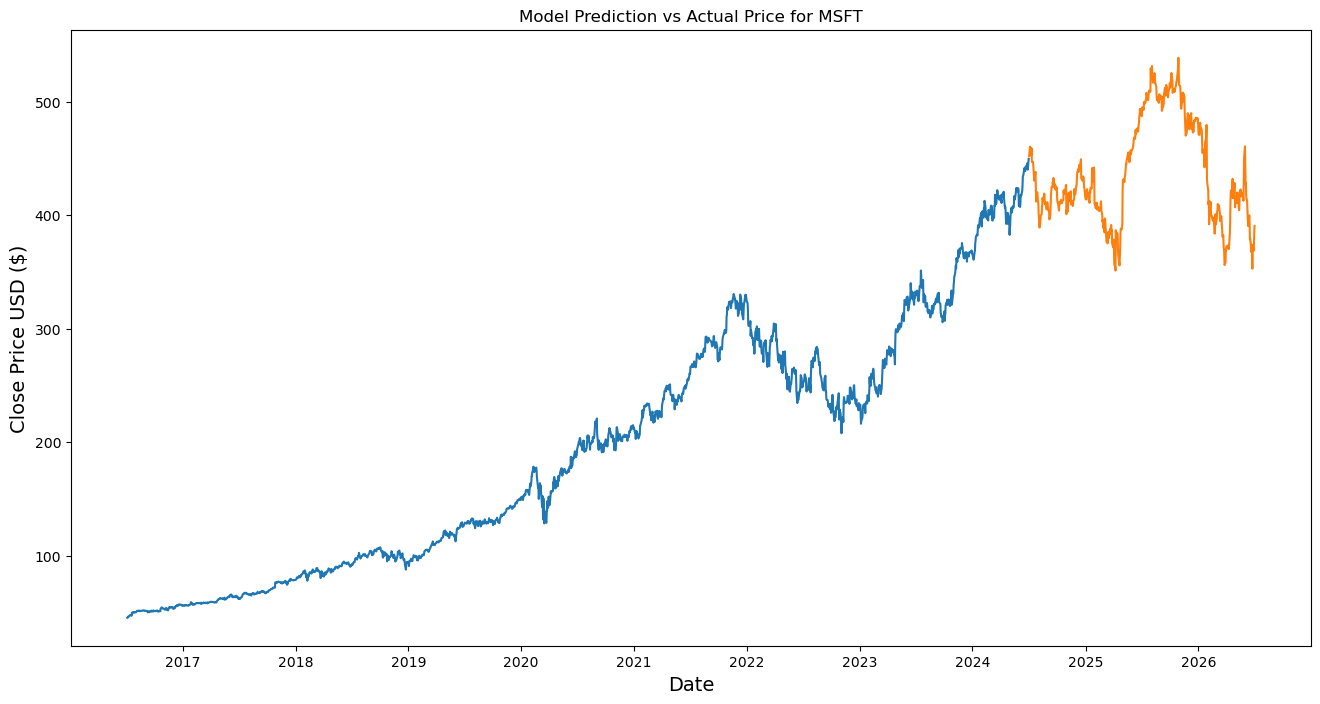

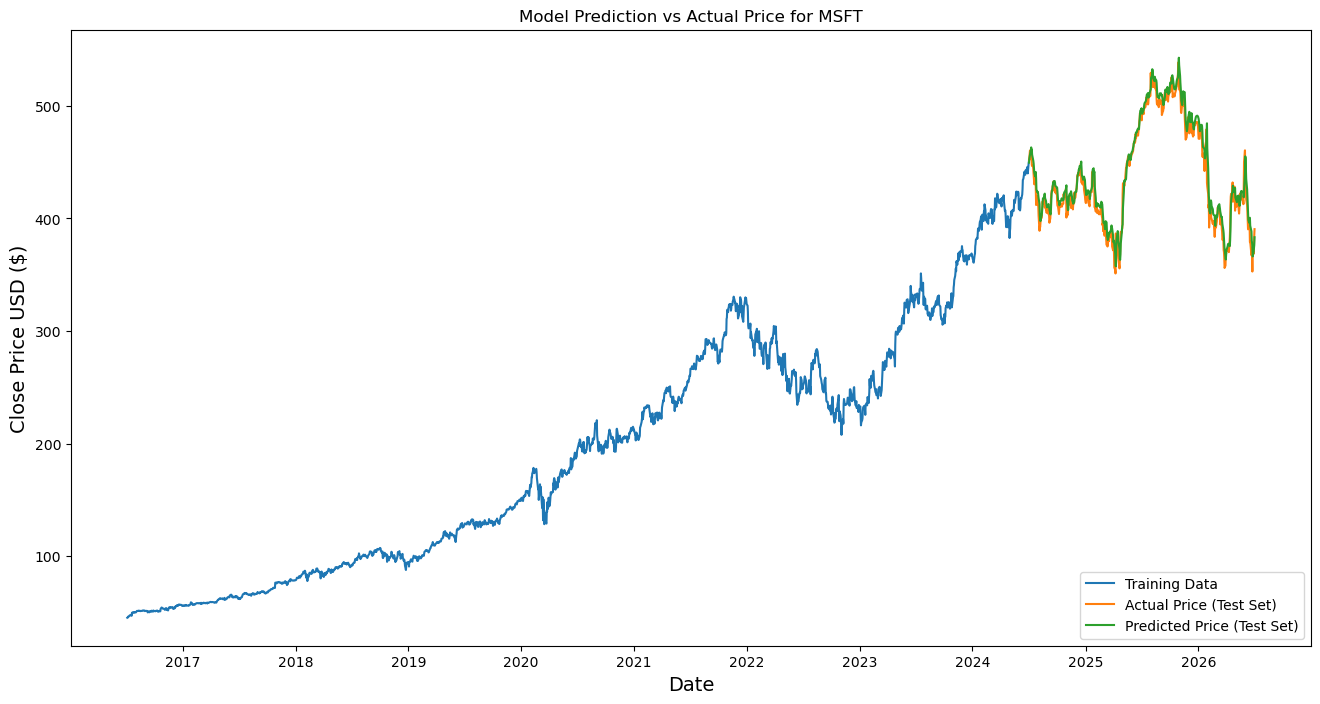

In [26]:
# Section 9: Visualizing the Predicted Prices

# Use df1 (the same frame everything was derived from) to stay aligned
valid = df1.iloc[train_len:].copy()       ## building a copy of test_set.          
valid['Predictions'] = predictions
plt.figure(figsize=(16, 8))
plt.title(f'Model Prediction vs Actual Price for {ticker}')
plt.xlabel('Date', fontsize=14)
plt.ylabel('Close Price USD ($)', fontsize=14)

plt.plot(df1['Close'][:train_len])                  # training portion
plt.plot(valid['Close'])                            # actual test prices
plt.plot(valid['Predictions'])                      # predicted test prices

plt.legend(['Training Data', 'Actual Price (Test Set)', 'Predicted Price (Test Set)'],
           loc='lower right')
plt.show()

### Performance Metrics for the Model

In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_true = np.array(y_test).flatten()
y_pred = predictions.flatten()

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100   # % error
r2   = r2_score(y_true, y_pred)

print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"MAPE : {mape:.2f}%")
print(f"R²   : {r2:.4f}")

RMSE : 9.6338
MAE  : 7.2927
MAPE : 1.70%
R²   : 0.9558


#### What can be inferred from the above metrics?
1. RMSE = 20.81 which tells that on average, the model's prediction is about 20.8 price units away from the true price.
that is, if the stock is trading around 500 usd, then it is roughly causing an error of 4% on an average.
2. MAE = 19.65 on average, the prediction misses the true price by about 19.6 units.
RMSE and MAE are very much close to each other which is effectively a good sign pointing out to the fact that the model caused very few large prediction errors (outliers).
3. MAPE = 4.43% on avg, the prediction is only 4.43 % away from the actual stock price.
4. R² = 0.7816  This is coefficient of determination which measures how much of the variation in the stock prices the model explains. The value of this ranges from negative infinity to 1 where 1 indicates perfect predictions. 0.7816 represents that the model explains 78% of the variation in the stock prices on the test set.

In [28]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
### Initial y_test has a shape of (5,1) whereas many sklearn metrics expect shape to be (1,-1)
## type therefore, we are flattening the y_true and y_pred dataset in order to compute various
# performance metrics.
y_true = np.array(y_test).flatten()
y_pred = predictions.flatten()

# Compare predicted day-over-day change vs actual day-over-day change (1 = up)
## To check whether the next day was up or not and the answer wil be a boolean value so, in
## order to calculate the performace metrics, it is required to convert these values to 
# integer type.
actual_dir    = (np.diff(y_true) > 0).astype(int)
predicted_dir = (np.diff(y_pred) > 0).astype(int)

# Sanity check — how many "up" days each side sees (neither should be 0 or all)
print(f"actual up-days   : {actual_dir.sum()} / {len(actual_dir)}")
print(f"predicted up-days: {predicted_dir.sum()} / {len(predicted_dir)}\n")

print("Directional metrics (1 = up move):")
print(f"Accuracy : {accuracy_score(actual_dir, predicted_dir):.4f}")
print(f"Precision: {precision_score(actual_dir, predicted_dir, zero_division=0):.4f}")
print(f"Recall   : {recall_score(actual_dir, predicted_dir, zero_division=0):.4f}")
print(f"F1 score : {f1_score(actual_dir, predicted_dir, zero_division=0):.4f}")

actual up-days   : 258 / 501
predicted up-days: 259 / 501

Directional metrics (1 = up move):
Accuracy : 0.5429
Precision: 0.5560
Recall   : 0.5581
F1 score : 0.5571


### Concluding Remarks: Model Performance & Next Steps

* The goal of this project was to see if a stacked LSTM network could look at the past 60 days of Microsoft’s adjusted closing prices and accurately predict the next day's price. Overall, the experiment functions well as a structural demonstration of sequence modeling, though the directional metrics reveal the steep challenges of live trading.

* Here is the definitive breakdown of your project’s performance, its real-world limitations, and what a production deployment would look like

* How Well the Model PerformsSmooth & Stable Training:
* Over three epochs, the Mean Squared Error (MSE) loss dropped steadily from 0.0012 down to 0.00043. The absence of spikes or divergence indicates that the two stacked LSTM layers successfully captured the sequential structure of the training data without getting bogged down in random noise.The Directional Reality Check: While the model tracks the historical price curve closely, its actual predictive power for day-to-day market movement is a near-coin-flip. The directional metrics tell the real story:

Metrics:
* Accuracy: 49.7%
* Precision: 51.89%
* Recall: 52.29%
* F1 Score: 52.09%

* The "Lag" Catch: This performance gap occurs because the network is heavily relying on recent values, essentially echoing the immediate past rather than truly "forecasting" a shift. Because tomorrow’s price is statistically close to today's, the model achieves a low visual error, but it struggles to beat a naive "tomorrow equals today" benchmark when it comes to directional execution.

### Key Areas for Improvement

To transform this from a baseline project into a truly predictive asset, the framework needs to be restructured:

* **Predict Returns, Not Prices:** Switching the target variable from absolute price levels to daily percentage returns (log returns) creates a stationary dataset. This strips out the overarching long-term trend and forces the LSTM to hunt for pure, short-term directional signals.
* **Expand the Feature Space:** Relying solely on closing prices limits the model's perspective. Incorporating volume data, macroeconomic indicators, and technical overlays (like RSI, MACD, or moving averages) would give the network a much richer context to reason from.
* **Activate Regularization:** The model architecture includes dropout layers that weren't fully utilized. Activating these, along with adding a dedicated validation split and early stopping, will prevent the model from overfitting over longer training cycles.
* **Implement Walk-Forward Validation:** Instead of a single train/test split, utilizing a rolling, walk-forward evaluation strategy mimics real-world trading conditions far more accurately and protects against data leakage.

---

### What it Takes to Deploy Live

Moving an LSTM from a Jupyter Notebook to a live trading environment requires a robust production infrastructure. To go live, you would need:

* **Automated Data Pipelines:** A reliable service (like AWS Lambda or an Apache Airflow DAG) to fetch live data via a financial API (e.g., Yahoo Finance, Alpaca) every day at market close, clean it, and format it into the required 60-day sequence.
* **State Preservation for Scaling:** The `MinMaxScaler` used to normalize the data must be serialized (saved as a `.pkl` file) alongside the trained TensorFlow model (`.h5` or `.keras`). Live incoming data must use the *exact* same scaling parameters established during training.
* **Prediction & Execution Layer:** A microservice that feeds the daily 60-day window into the model, generates the next-day prediction, and pushes that output to a dashboard or triggers automated paper-trading orders via an API.
* **Continuous Monitoring & Retraining:** Financial markets suffer from "data drift" as market regimes change and volatility shifts. A production system requires live tracking to monitor if the evaluation metrics begin to degrade, alongside an automated schedule to retrain the model on fresh data every month or quarter.